In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('tourism.csv')
import warnings
warnings.filterwarnings('ignore')

In [2]:
df.head()

,Location,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,kuBZRkVsAR,India,Nature,948853,1.32,84388.38,Yes
1,aHKUXhjzTo,USA,Historical,813627,2.01,802625.60,No
2,dlrdYtJFTA,Brazil,Nature,508673,1.42,338777.11,Yes
3,DxmlzdGkHK,Brazil,Historical,623329,1.09,295183.60,Yes
4,WJCCQlepnz,France,Cultural,124867,1.43,547893.24,No


In [3]:
df=df.drop(['Location'],axis=1)
df.head()

,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,India,Nature,948853,1.32,84388.38,Yes
1,USA,Historical,813627,2.01,802625.60,No
2,Brazil,Nature,508673,1.42,338777.11,Yes
3,Brazil,Historical,623329,1.09,295183.60,Yes
4,France,Cultural,124867,1.43,547893.24,No


In [4]:
df['Accommodation_Available'] = df['Accommodation_Available'].astype(str).str.lower().map({'yes': 1, 'no': 0})

In [5]:
df.head()

,Country,Category,Visitors,Rating,Revenue,Accommodation_Available
0,India,Nature,948853,1.32,84388.38,1
1,USA,Historical,813627,2.01,802625.60,0
2,Brazil,Nature,508673,1.42,338777.11,1
3,Brazil,Historical,623329,1.09,295183.60,1
4,France,Cultural,124867,1.43,547893.24,0


In [6]:
df.shape

(5989, 6)

In [7]:
pd.isnull(df).sum()

Country                    0
Category                   0
Visitors                   0
Rating                     0
Revenue                    0
Accommodation_Available    0
dtype: int64

In [8]:
df.describe()

,Visitors,Rating,Revenue,Accommodation_Available
count,5989.000000,5989.000000,5989.000000,5989.000000
mean,501016.089497,3.009347,499479.367253,0.503089
std,289783.294978,1.155980,286743.225211,0.500032
min,1108.000000,1.000000,1025.810000,0.000000
25%,252789.000000,2.010000,251410.450000,0.000000
50%,500831.000000,3.000000,494169.350000,1.000000
75%,751371.000000,4.010000,742241.240000,1.000000
max,999982.000000,5.000000,999999.490000,1.000000


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5989 entries, 0 to 5988
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Country                  5989 non-null   object 
 1   Category                 5989 non-null   object 
 2   Visitors                 5989 non-null   int64  
 3   Rating                   5989 non-null   float64
 4   Revenue                  5989 non-null   float64
 5   Accommodation_Available  5989 non-null   int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 280.9+ KB


In [10]:
df.columns

Index(['Country', 'Category', 'Visitors', 'Rating', 'Revenue',
       'Accommodation_Available'],
      dtype='object')

<Axes: >

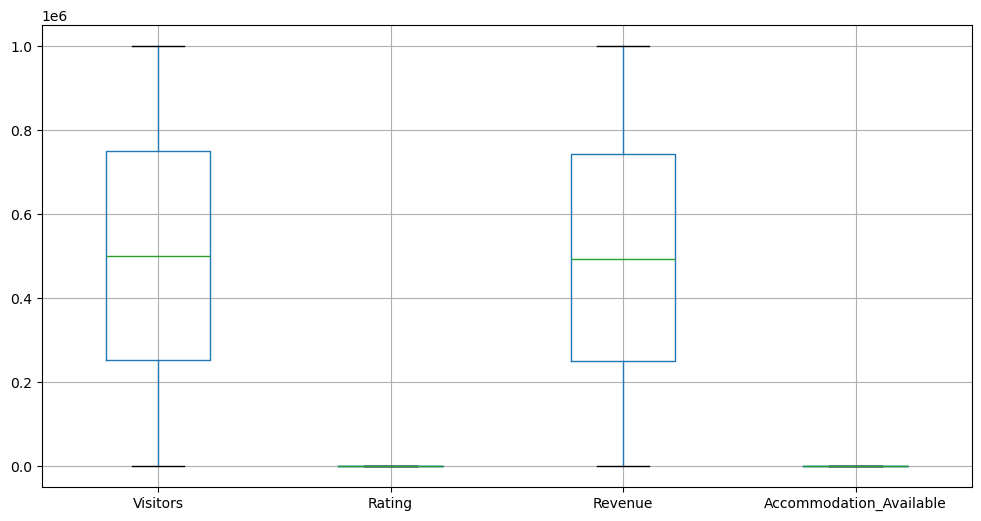

In [11]:
plt.figure(figsize=(12,6))
df.boxplot()

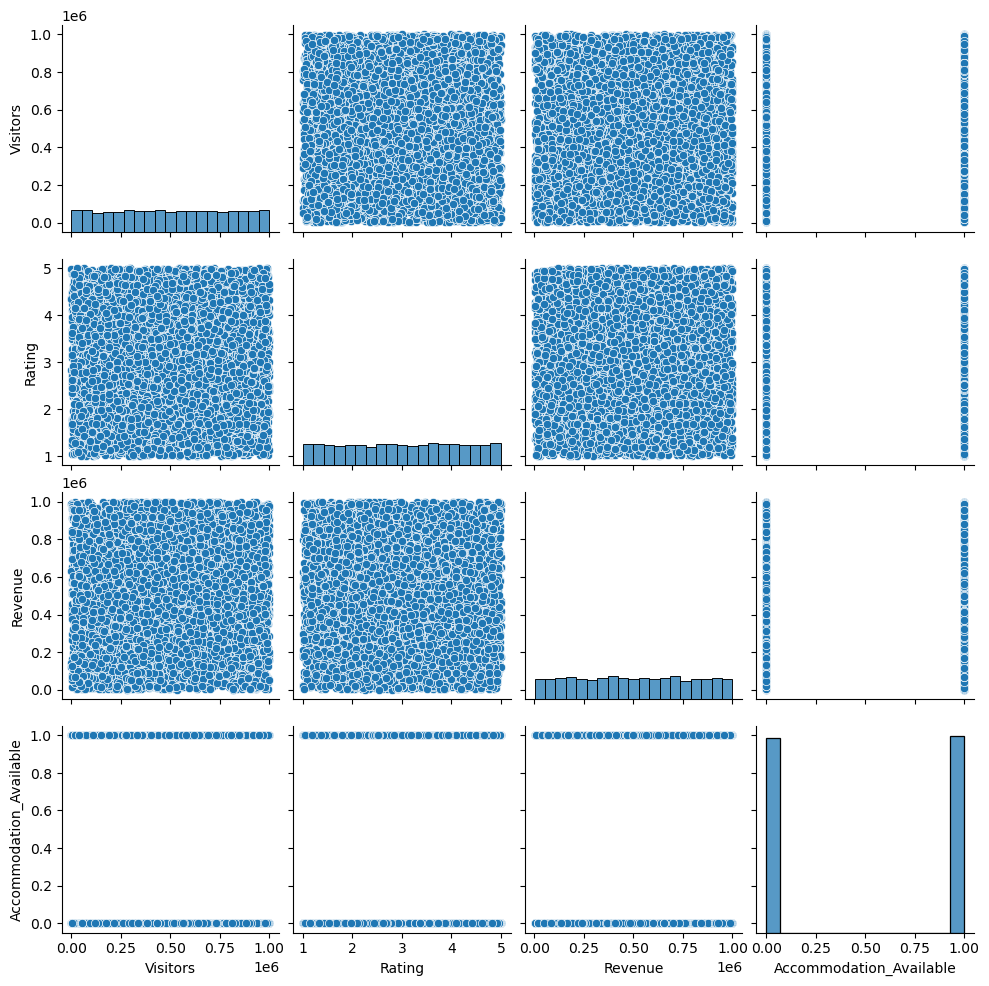

In [12]:
sns.pairplot(df)

In [13]:
df['Category'].value_counts()

Category
Adventure     1037
Urban         1006
Cultural       998
Beach          998
Historical     994
Nature         956
Name: count, dtype: int64

In [94]:
country_counts = df['Country'].value_counts()
total_revenue_per_country = df.groupby('Country')['Revenue'].sum()
pd.set_option('display.float_format', '{:,.2f}'.format)
print("\nTotal Revenue per Country:")
print(total_revenue_per_country)


Total Revenue per Country:
Country
Australia   412,663,332.26
Brazil      426,783,200.27
China       398,432,378.25
Egypt       460,594,792.53
France      410,526,642.27
India       454,676,299.35
USA         427,705,285.55
Name: Revenue, dtype: float64


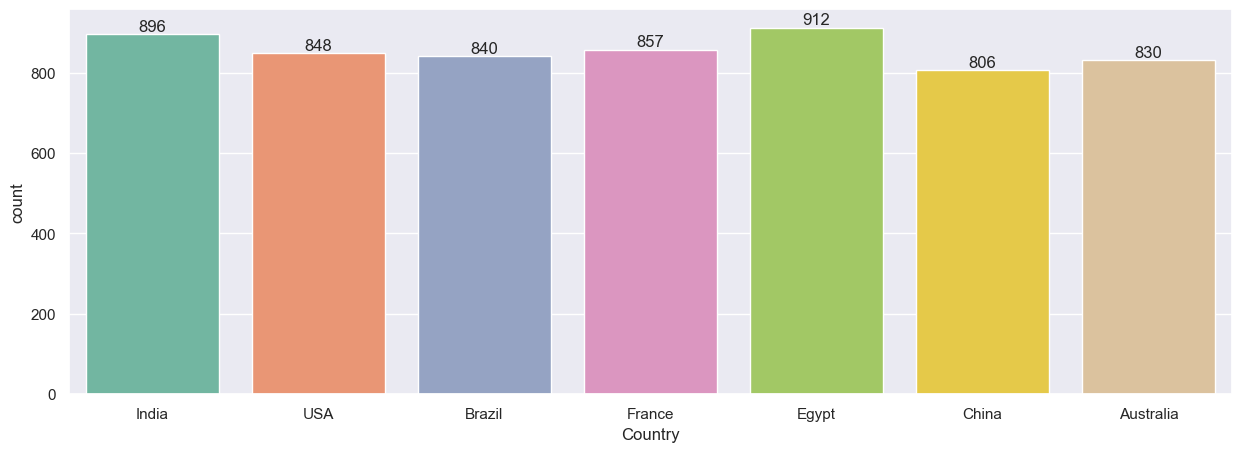

In [79]:
ax=sns.countplot(data=df,x='Country',palette='Set2')
sns.set(rc={'figure.figsize':(15,5)})
for bars in ax.containers:
    ax.bar_label(bars)

Insights:- The visitors are more from the countries of india and egypt,The visitors are moderate from countries like usa,brazil and france,The visitors from the countries of china and australia are less compared to others.More the visitors,more the revenue is generated for the country

<Axes: xlabel='Category', ylabel='Rating'>

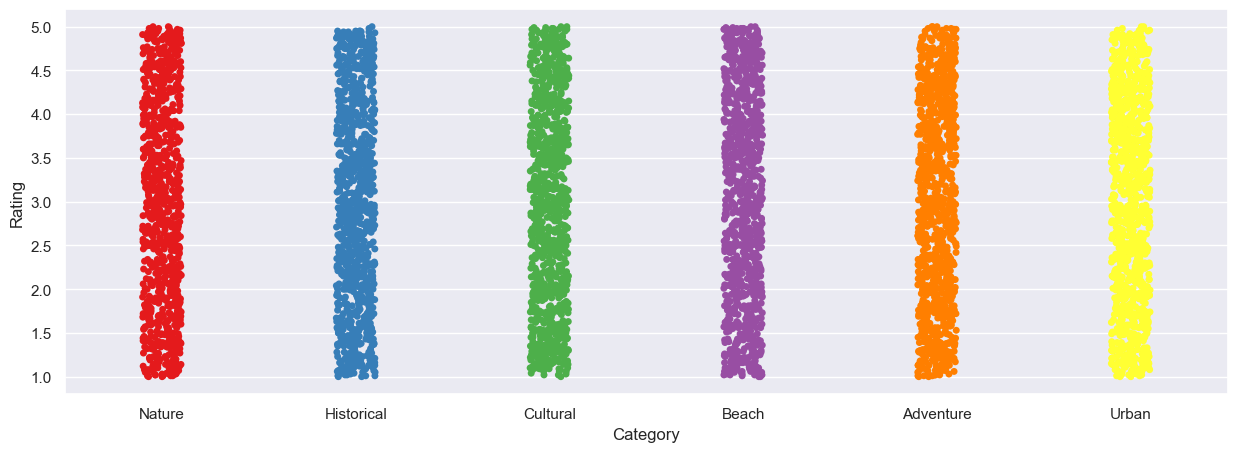

In [17]:
sns.stripplot(x='Category',y='Rating',data=df,palette='Set1')

Insights:- In this there is almost equal rating given to the categories like adventure,beach,urban,cultural and historical and the rating for nature is lesser compared to other categories

<Axes: xlabel='Category', ylabel='Revenue'>

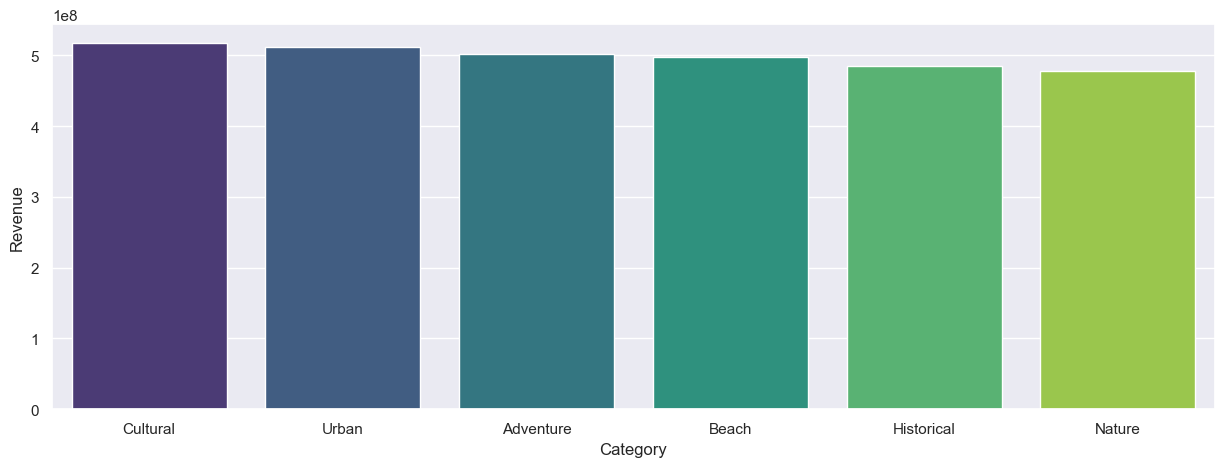

In [19]:
sns_data=df.groupby(['Category'],as_index=False)['Revenue'].sum().sort_values(by='Revenue',ascending=False)
sns.set(rc={'figure.figsize':(15,5)})
sns.barplot(x='Category',y='Revenue',data=sns_data,palette='viridis')

Insights:- The revenue was generated almost same in the categories of adventure,beach,urban,cultural but the revenue for the categories of historical and nature was generated bit lesser compared to other category

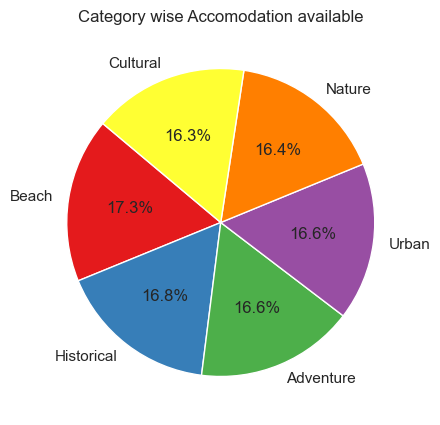

In [21]:
sns_data = df.groupby(['Category'], as_index=False)['Accommodation_Available'].sum().sort_values(by='Accommodation_Available', ascending=False)
plt.figure(figsize=(5, 5))  
plt.pie(sns_data['Accommodation_Available'], labels=sns_data['Category'], autopct='%1.1f%%', colors=plt.cm.Set1.colors, startangle=140)
plt.title("Category wise Accomodation available")
plt.show()

Insights:-There is a more accomodation for beach category compared to other categories

Segmentation- Using K nearest neighbors

In [24]:
x=df.drop('Revenue',axis=1)
y=df['Revenue']

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=25)

In [26]:
print(x.dtypes)

Country                     object
Category                    object
Visitors                     int64
Rating                     float64
Accommodation_Available      int64
dtype: object


In [27]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False) 
encoded_cols = encoder.fit_transform(x[['Country']])  
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['Country']))
x = pd.concat([x.drop(columns=['Country']), encoded_df], axis=1)

In [28]:
encoder = OneHotEncoder(drop='first', sparse_output=False) 
encoded_cols = encoder.fit_transform(x[['Category']])  
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(['Category']))
x = pd.concat([x.drop(columns=['Category']), encoded_df], axis=1)

In [29]:
categorical_cols = x.select_dtypes(include=['object']).columns  
encoder = OneHotEncoder(drop='first', sparse_output=False)  
encoded_cols = encoder.fit_transform(x[categorical_cols])
encoded_df = pd.DataFrame(encoded_cols, columns=encoder.get_feature_names_out(categorical_cols))
x = pd.concat([x.drop(columns=categorical_cols), encoded_df], axis=1)

In [30]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_scaled = sc.fit_transform(x) 

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)

In [32]:
from sklearn.neighbors import KNeighborsRegressor
model=KNeighborsRegressor(n_neighbors=12)
model.fit(x_train,y_train)

KNeighborsRegressor(n_neighbors=12)

In [33]:
y_pred=model.predict(x_test)

In [34]:
from sklearn.metrics import mean_squared_error
mean_squared_error(y_pred,y_test)

87819523520.15782

In [35]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_pred,y_test)

250593.89755912634

In [36]:
from sklearn.metrics import r2_score
r2_score(y_pred,y_test)

-11.057908756704581

Segmentation- Using K Mans Clustering

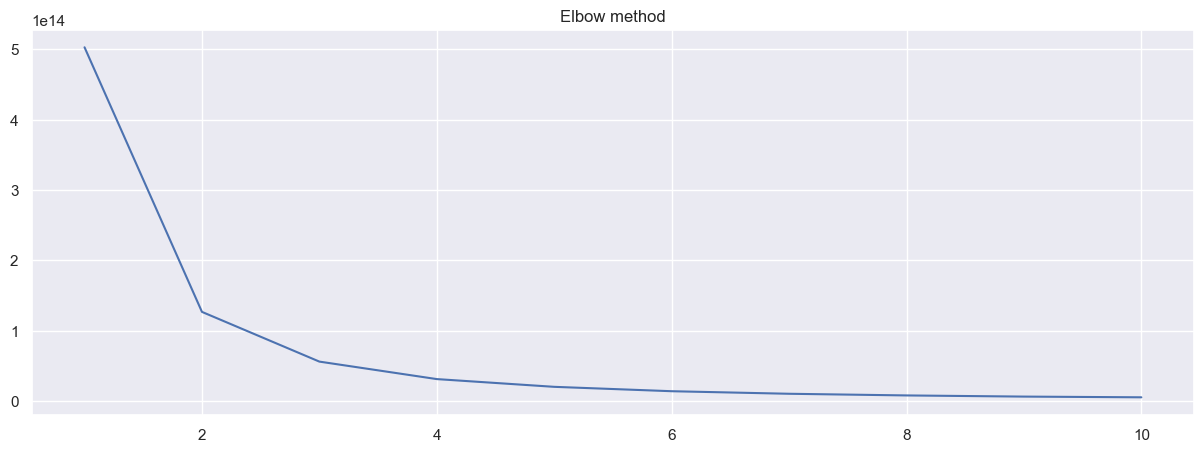

In [38]:
from sklearn.cluster import KMeans
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1,11),wcss)
plt.title('Elbow method')
plt.show()

In [39]:
kmeans=KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans=kmeans.fit_predict(x)

In [40]:
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.decomposition import PCA
db_scores = []
silhouette_scores = []
for k in range(2, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(x_scaled)
    db_index = davies_bouldin_score(x_scaled, clusters)
    silhouette_avg = silhouette_score(x_scaled, clusters)
    db_scores.append(db_index)
    silhouette_scores.append(silhouette_avg)
    print(f"Number of clusters: {k}, DB Index: {db_index}, Silhouette Score: {silhouette_avg}")

Number of clusters: 2, DB Index: 3.1041488938590955, Silhouette Score: 0.0918921735579091
Number of clusters: 3, DB Index: 3.3307763222826368, Silhouette Score: 0.08235104561391092
Number of clusters: 4, DB Index: 2.84871262781137, Silhouette Score: 0.0994377586538582
Number of clusters: 5, DB Index: 1.9651271598443478, Silhouette Score: 0.21140955930784736
Number of clusters: 6, DB Index: 2.2341030941718025, Silhouette Score: 0.16357745780142557
Number of clusters: 7, DB Index: 1.9414005384553639, Silhouette Score: 0.18445985681011254
Number of clusters: 8, DB Index: 1.7775421906084894, Silhouette Score: 0.20318910946889154
Number of clusters: 9, DB Index: 1.7098405077821393, Silhouette Score: 0.19012014521130735
Number of clusters: 10, DB Index: 1.737340948433646, Silhouette Score: 0.17050830580247442


In [41]:
optimal_clusters = np.argmin(db_scores) + 2  
print(f"Optimal number of clusters: {optimal_clusters}")

Optimal number of clusters: 9


In [42]:
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
final_clusters = kmeans.fit_predict(x_scaled)
df['Cluster'] = final_clusters


In [43]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_scaled)
df['PCA1'] = x_pca[:, 0]
df['PCA2'] = x_pca[:, 1]


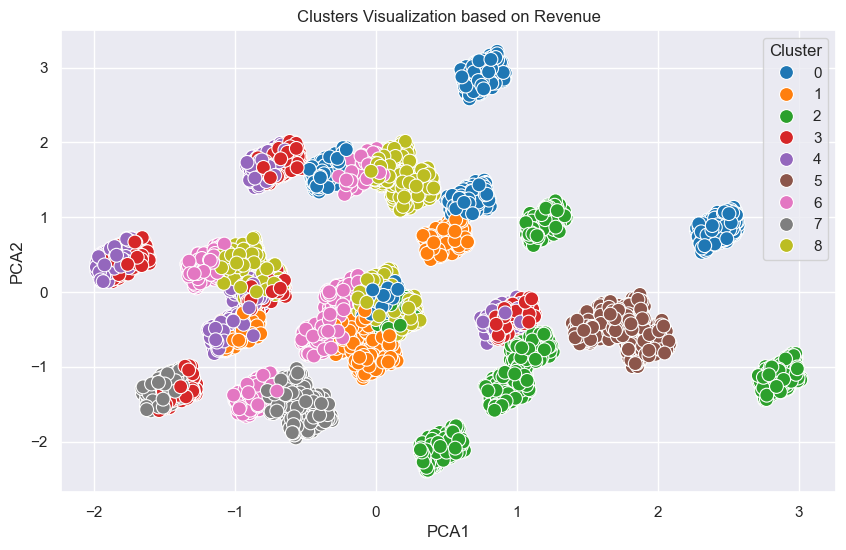

In [44]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='tab10', s=100)
plt.title('Clusters Visualization based on Revenue')
plt.show()